# Evaluación Parcial 1 – Fundamentos de Deep Learning
## Clasificación de imágenes Fashion‑MNIST con MLP

**Objetivo:** Implementar una red neuronal multicapa (MLP) para clasificar imágenes de moda en 10 categorías.

**Dataset:** Fashion‑MNIST.

**Integrantes:**
- Matías Gutiérrez
- David Larenas
- Francisco Silva

---

## Mapeo Notebook → Indicadores de la Rúbrica

| Sección del Notebook | Indicador(es) Encargo (IEE) | Indicador(es) Presentación (IP) |
|----------------------|-----------------------------|----------------------------------|
| 1. Carga y preprocesamiento | IEE 1.1.1 | IP 1.1.1 |
| 2. Definición modelo base | IEE 1.1.2 (configuración inicial), IEE 1.2.1 (funciones base), IEE 1.3.1 (uso TF/Keras) | IP 1.2.1, IP 1.3.1 |
| 2.1 Entrenamiento inicial | IEE 1.1.2, IEE 1.1.3 (primer experimento implícito) | IP 1.1.2 |
| 2.2 Experimento 1 – Learning rate | IEE 1.1.3, IEE 1.1.4 (ajuste) | IP 1.1.2, IP 1.1.3 |
| 2.3 Experimento 2 – Batch size | IEE 1.1.3, IEE 1.1.4 | IP 1.1.2, IP 1.1.3 |
| 2.4 Experimento 3 – Arquitectura | IEE 1.1.3, IEE 1.1.4 | IP 1.1.2, IP 1.1.3 |
| 3. Comparación funciones de activación/error | IEE 1.2.1, IEE 1.2.2, IEE 1.2.3 | IP 1.2.1, IP 1.2.2, IP 1.2.3 |
| 4. Optimización y Regularización | IEE 1.3.2, IEE 1.3.3 | IP 1.3.2, IP 1.3.3 |
| 5. Evaluación del modelo final | IEE 1.4.1, IEE 1.4.2 | IP 1.4.1, IP 1.4.2 |
| 6. Comparación de configuraciones | IEE 1.4.3 | IP 1.4.3 |
| 7. Conclusiones | (soporte para todos los IEE) | (soporte para todos los IP) |

*Los indicadores IP se refieren a la defensa oral, así que las gráficas y explicaciones que dejéis en el notebook os servirán de apoyo directo.*

---

## Importaciones

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.callbacks import EarlyStopping, ModelCheckpoint

## 1. Carga y Preprocesamiento de Datos

### Carga del Dataset (Fashion‑MNIST)

Utilizamos la función `keras.datasets.fashion_mnist.load_data()`, que retorna dos tuplas:  
- `(train_imgs, train_labs)`: 60 000 imágenes de entrenamiento y sus etiquetas.  
- `(test_imgs, test_labs)`: 10 000 imágenes de prueba y sus etiquetas.  

Cada imagen es una matriz de 28×28 píxeles en escala de grises (intensidad entre 0 y 255). Las etiquetas son enteros de 0 a 9, cada uno representando una categoría de moda.

In [3]:
# Cargar datos
(train_imgs, train_labs), (test_imgs, test_labs) = keras.datasets.fashion_mnist.load_data()

print("Forma de train_imgs:", train_imgs.shape)
print("Forma de train_labs:", train_labs.shape)
print("Forma de test_imgs :", test_imgs.shape)
print("Forma de test_labs :", test_labs.shape)
print("Tipo de datos de imagen:", train_imgs.dtype)
print("Rango de valores de píxel: de", train_imgs.min(), "a", train_imgs.max())

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Forma de train_imgs: (60000, 28, 28)
Forma de train_labs: (60000,)
Forma de test_imgs : (10000, 28, 28)
Forma de test_labs : (10000,)
Tipo de datos de imagen: uint8
Rango de valores de píxel: de 0 a 255


**Justificación:** Verificar las dimensiones y el rango de datos es el primer paso para asegurar que la carga ha sido correcta y para planificar el preprocesamiento. Como las imágenes están en una escala de 0 a 255, será necesario normalizarlas.

### Mapeo de etiquetas

El dataset asigna un número entero a cada categoría. Definimos una lista con los nombres correspondientes para que las visualizaciones y métricas sean interpretables.

In [4]:
# Estos son los nombres de las 10 clases de Fashion‑MNIST
class_names = ['T‑shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print("Clases:", class_names)

Clases: ['T‑shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


### Visualización de muestras

Mostramos una grilla de 5×5 imágenes del conjunto de entrenamiento con sus etiquetas reales. Esto nos permite validar visualmente la relación imagen‑etiqueta y familiarizarnos con los tipos de prendas.

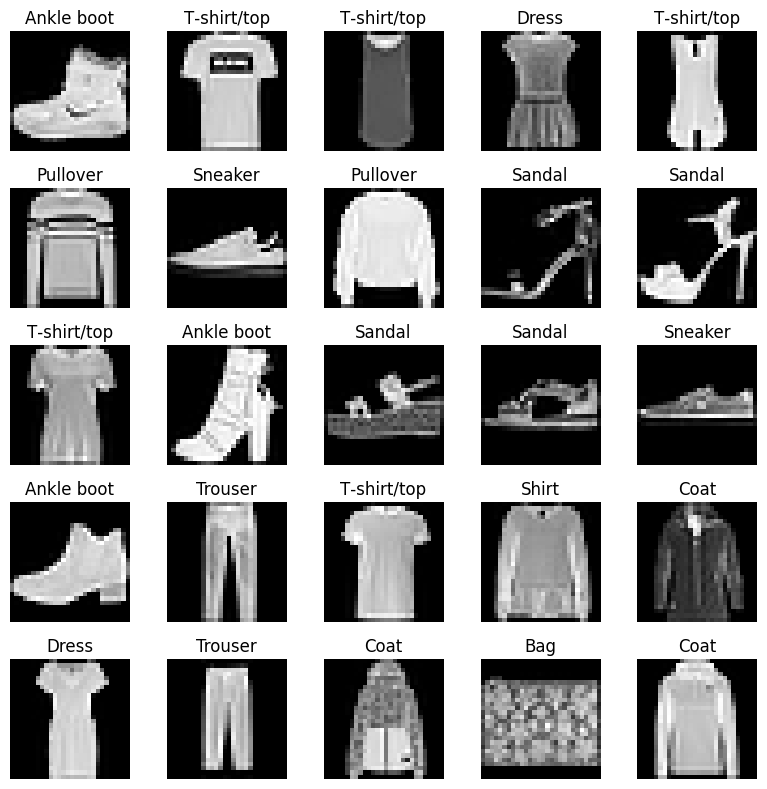

In [5]:
# Grilla 5x5
fig, axes = plt.subplots(5, 5, figsize=(8, 8))
axes = axes.ravel()
for i in range(25):
    axes[i].imshow(train_imgs[i], cmap='gray')
    axes[i].set_title(class_names[train_labs[i]])
    axes[i].axis('off')
plt.tight_layout()
plt.show()

**Justificación:** La inspección visual directa complementa la verificación numérica y permite detectar posibles errores en el etiquetado.

### Balance de clases

Una distribución equilibrada evita que el modelo favorezca a las clases mayoritarias. Comprobamos la frecuencia de cada clase en el conjunto de entrenamiento.

T‑shirt/top : 6000
Trouser     : 6000
Pullover    : 6000
Dress       : 6000
Coat        : 6000
Sandal      : 6000
Shirt       : 6000
Sneaker     : 6000
Bag         : 6000
Ankle boot  : 6000


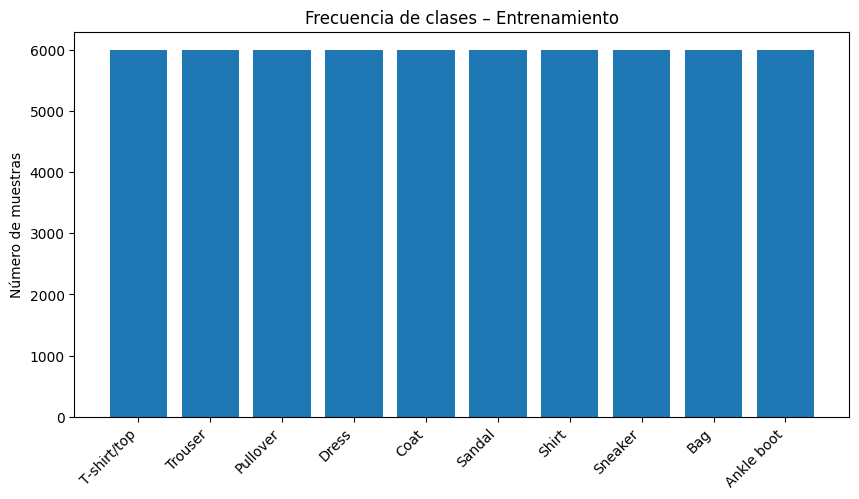

In [6]:
# Conteo de etiquetas
unique, counts = np.unique(train_labs, return_counts=True)
freq = {class_names[u]: c for u, c in zip(unique, counts)}

# Mostrar frecuencias
for name, count in freq.items():
    print(f"{name:12s}: {count}")

# Gráfico de barras
plt.figure(figsize=(10, 5))
plt.bar(range(10), counts, tick_label=class_names)
plt.title('Frecuencia de clases – Entrenamiento')
plt.ylabel('Número de muestras')
plt.xticks(rotation=45, ha='right')
plt.show()

**Justificación:** Confirmamos que las 10 clases están balanceadas (6 000 muestras cada una). Por tanto, la exactitud (accuracy) será una métrica adecuada para evaluar el desempeño global, ya que no hay una clase desproporcionada que pueda sesgarla.

### Preprocesamiento para MLP

El Perceptrón Multicapa (MLP) espera como entrada vectores unidimensionales. Por tanto:
1. **Aplanamos** cada imagen de 28×28 a un vector de 784 píxeles.  
2. **Normalizamos** los valores de intensidad dividiendo por 255, llevándolos al intervalo [0,1].  

Esta normalización es crucial: valores grandes de entrada provocan gradientes de gran magnitud, lo que puede desestabilizar el descenso del gradiente (backpropagation) y ralentizar la convergencia. Con entrada normalizada, el gradiente es más suave y los pesos se actualizan de forma más controlada (ver Experiencia de Aprendizaje 1, unidades 1.3 y 1.4).

In [7]:
# Aplanado y normalización
X_train = train_imgs.reshape(-1, 28*28) / 255.0
X_test  = test_imgs.reshape(-1, 28*28) / 255.0

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Valores X_train en [", X_train.min(), ",", X_train.max(), "]")

X_train shape: (60000, 784)
X_test shape : (10000, 784)
Valores X_train en [ 0.0 , 1.0 ]


### One‑hot encoding de las etiquetas

Para un clasificador con salida softmax y pérdida de entropía cruzada categórica, las etiquetas deben representarse como vectores one‑hot. Así, si la etiqueta real es la clase 3, el vector correspondiente será `[0,0,0,1,0,0,0,0,0,0]`. Esto permite calcular correctamente la divergencia entre la distribución predicha y la real.

In [8]:
Y_train = keras.utils.to_categorical(train_labs, 10)
Y_test  = keras.utils.to_categorical(test_labs, 10)

print("Y_train shape:", Y_train.shape)
print("Y_test shape :", Y_test.shape)
print("Ejemplo: etiqueta original", train_labs[0], "→ one‑hot", Y_train[0])

Y_train shape: (60000, 10)
Y_test shape : (10000, 10)
Ejemplo: etiqueta original 9 → one‑hot [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


**Justificación:** La entropía cruzada categórica comparará directamente la salida softmax (un vector de probabilidades) con este vector one‑hot. Cualquier otra representación no sería compatible con la función de pérdida elegida.

### Resumen

En resumen se podria decir que realizamos lo siguiente:
- Cargamos 60 000 imágenes de entrenamiento y 10 000 de prueba.  
- Verificamos el balance de clases.  
- Aplanamos las imágenes a 784 características y normalizamos a [0,1].  
- Convertimos las etiquetas a formato one‑hot.  

## 2. Definición de Modelo Base

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

model_base = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model_base.compile(
    loss='categorical_crossentropy',
    optimizer=keras.optimizers.SGD(learning_rate=0.01),
    metrics=['accuracy']
)
model_base.summary()

### 2.1 Entrenamiento inicial (20 épocas, batch_size=32)

In [ ]:
history = model_base.fit(X_train, Y_train,
                         epochs=20, batch_size=32,
                         validation_split=0.2)

In [ ]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()

### 2.2 Experimento 1: Variar learning rate

In [ ]:
# Experimento 1

In [ ]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()

### 2.3 Experimento 2: Variar batch size (16, 64)

In [ ]:
# Experimento 2

In [ ]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()

### 2.4 Experimento 3: Variar arquitectura (capas y neuronas)

In [ ]:
# Experimento 3

In [ ]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()

Para cada experimento se presentan gráficos comparativos y una tabla con pérdida y accuracy finales.
Se justifica, por ejemplo, que un learning rate alto provoca divergencia.

## 3. Comparación de funciones de activación y error

In [ ]:
# Modelos con activación 'sigmoid', 'tanh' y 'relu'
# Se entrena cada uno con los mismos hiperparámetros base
# Comparativa en tabla: loss, accuracy, tiempo
# Se muestra gráfico de barras.

**Justificación:** ReLU evita desvanecimiento de gradiente y converge más rápido. La entropía cruzada es adecuada para clasificación.

## 4. Optimización y Regularización

### 4.1 Dropout y Batch Normalization

In [ ]:
model_reg = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax')
])

### 4.2 Early Stopping

In [ ]:
es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model_reg.compile(
    loss='categorical_crossentropy',
    optimizer=keras.optimizers.SGD(learning_rate=0.01),
    metrics=['accuracy']
)

history_reg = model_reg.fit(X_train, Y_train,
                             epochs=100, batch_size=32,
                             validation_split=0.2,
                             callbacks=[es])

### 4.3 Cambio de optimizador a Adam

In [ ]:
optimizer = keras.optimizers.Adam(learning_rate=0.001)
model_reg.compile(optimizer=optimizer, ...)

Comparativa visual (curvas de entrenamiento con y sin regularización) y tabla de métricas.

## 5. Evaluación del modelo final

In [ ]:
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Cargar el mejor modelo guardado (si se usó ModelCheckpoint)
# final_model = keras.models.load_model('best_model.h5')
# O usar el último modelo entrenado

y_pred = final_model.predict(X_test).argmax(axis=1)
y_true = test_labs   # etiquetas en enteros

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.show()

**Interpretación:** Precisión global alta, pero clase ’cami’ tiene recall bajo. Se analizan posibles causas.

## 6. Comparación de configuraciones

In [ ]:
# Tablas de resumenes
# Graficos de barras comparando las metricas

## 7. Conclusiones

Dejas conclusiones de los resultados y el proceso de experimentación. Indicar hallazgos y también explicar importancia de cada proceso según sea comprendido.